In [1]:
import numpy as np

In [2]:
x = 0
th = 0.01
tau = 2
p = 0.05
pb = 0.5
t = 3000
l = 50
n_s = 100
k = 3
seed = 0

In [3]:
for ii, t in enumerate([3000, 30000]):
    for k in range(1, 11):
        for jj in range(10):
            seed = jj + (k - 1) * 10 + ii * 100
            np.random.seed(seed)
            n = n_s * k
            ret = np.zeros((t, n))
            for ki in range(k):
                xt = []
                for _ in range(t+l-1):
                    if np.random.random() < p:
                        x += 1
                    x -= x / tau
                    if x < th:
                        x = 0
                    xt.append(x)
                xt = np.array(xt)
                for i, r in enumerate(np.random.randint(l, size=n_s)):
                    ret[:, ki*n_s+i] = xt[r:r+t]
            ret *= np.random.exponential(size=(t, n))
            np.savetxt(
                "t{}/gen_n{}_k{}_l{}_t{}_seed{}.csv".format(t, str(n), str(k), str(l), str(t), str(seed)),
                ret, delimiter=","
            )

In [4]:
t = 3000
for ii, m in enumerate([2, 0.5, 3, 1/3]):
    for k in [5]:
        for jj in range(10):
            seed = jj + (k - 1) * 10 + (ii + 1) * 1000
            np.random.seed(seed)
            n = n_s * k
            ret = np.zeros((t, n))
            for ki in range(k):
                xt = []
                for _ in range(t+l-1):
                    if np.random.random() < p:
                        x += 1
                    x -= x / tau
                    if x < th:
                        x = 0
                    xt.append(x)
                xt = np.array(xt)
                for i, r in enumerate(np.random.randint(l, size=n_s)):
                    ret[:, ki*n_s+i] = xt[r:r+t]
            ret *= np.random.gamma(shape=m, scale=1/m, size=(t, n))
            np.savetxt(
                "t{}/gen_n{}_k{}_l{}_t{}_seed{}.csv".format(t, str(n), str(k), str(l), str(t), str(seed)),
                ret, delimiter=","
            )

In [5]:
def gen_data(m, k=5, seed=0):
    t = 3000
    n = k * 100
    x = 0
    ret = np.zeros((t, n))
    np.random.seed(seed)
    for ki in range(k):
        xt = []
        for _ in range(t+l-1):
            if np.random.random() < p:
                x += 1
            x -= x / tau
            if x < th:
                x = 0
            xt.append(x)
        xt = np.array(xt)
        for i, r in enumerate(np.arange(100) // 2):
            ret[:, ki*n_s+i] = xt[r:r+t]
    ret *= np.random.gamma(shape=m, scale=1/m, size=ret.shape)
    ret[ret == 0] = ret[ret > 0].min()
    return ret

In [6]:
from matplotlib import pyplot as plt

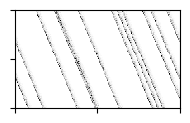

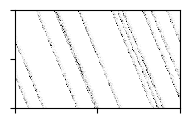

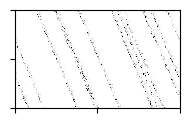

In [7]:
for mi, m in enumerate([3, 1, 1/3]):
    ret = gen_data(m, k=1, seed=0)
    plt.figure(figsize=(2, 2/1.5))
    plt.pcolor(ret[:200].T, vmax=8*ret.std(), cmap="binary")
    plt.xticks([0, 100, 200])
    plt.yticks([0, 50, 100])
    plt.tick_params(labelleft=False, labelbottom=False)
    plt.tight_layout()
    plt.savefig("figures/figsA/figsAa{}.png".format(mi))
    plt.show()

In [8]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

C:\Users\shunt\AppData\Local\Temp\ipykernel_17216\3909009210.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


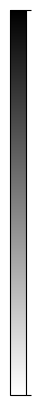

In [9]:
cmap = plt.get_cmap("binary")
norm = Normalize(vmin=0, vmax=100)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, ax = plt.subplots(figsize=(0.2, 5))
fig.colorbar(sm, cax=ax)
plt.yticks([0, 100])
plt.tick_params(labelright=False)
plt.tight_layout()
plt.savefig("figures/figsA/colormap.png")
plt.show()